# ДЗ 5

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import wave
import struct
import time
from sympy import Poly, Symbol
from tqdm.auto import tqdm

np.random.seed(42)

# Задание 1. Фурье-преобразование картинки

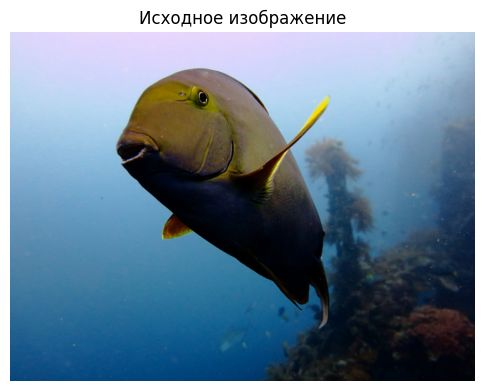

In [85]:
DATA = "suppl_4_4/"

im = Image.open(DATA + "im1.jpg")
img_array = np.array(im, dtype=float)

plt.figure(figsize=(6, 6))
plt.imshow(im)
plt.title("Исходное изображение")
plt.axis("off")
plt.show()

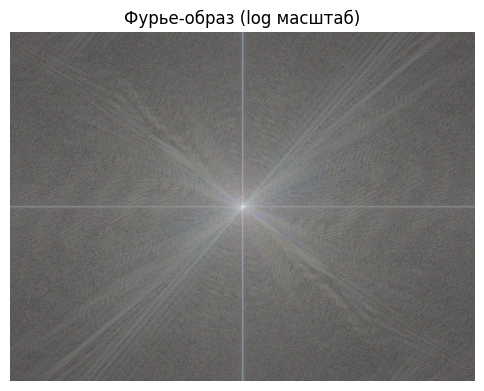

In [86]:
ft_channels = []
for ch in range(3):
    ft_channels.append(np.fft.fft2(img_array[:, :, ch]))

ft_image = np.stack(ft_channels, axis=-1)

ft_vis = np.zeros_like(img_array)
for ch in range(3):
    magnitude = np.abs(np.fft.fftshift(ft_channels[ch]))
    log_mag = np.log1p(magnitude)
    log_mag = log_mag / log_mag.max() * 255
    ft_vis[:, :, ch] = np.clip(np.round(log_mag), 0, 255).astype(np.uint8)

out_img = Image.fromarray(ft_vis.astype(np.uint8))
out_img.save(DATA + "out.jpg")

plt.figure(figsize=(6, 6))
plt.imshow(ft_vis.astype(np.uint8))
plt.title("Фурье-образ (log масштаб)")
plt.axis("off")
plt.show()

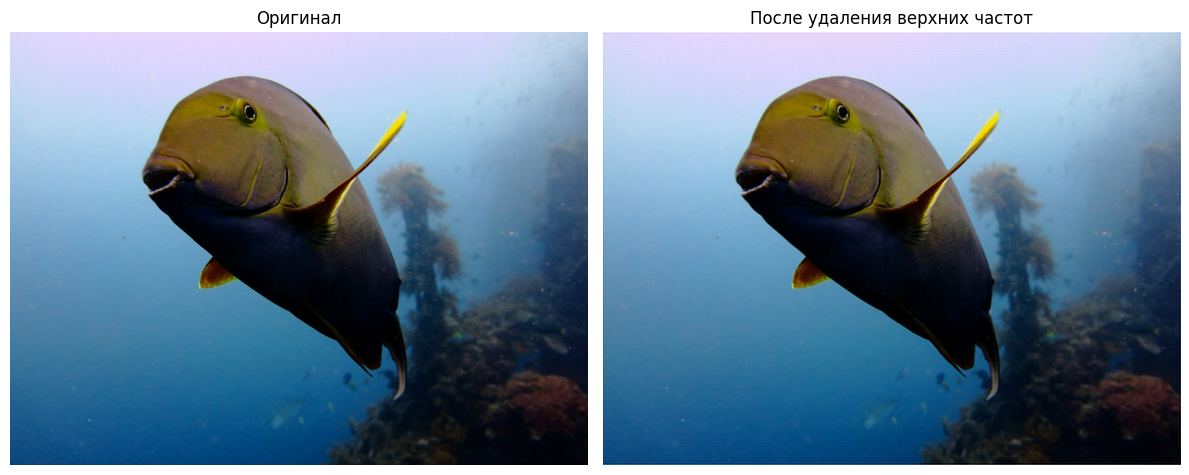

In [87]:
H, W = img_array.shape[:2]
freq_cutoff_y = H // 4
freq_cutoff_x = W // 4

result_channels = []
for ch in range(3):
    ft = ft_channels[ch].copy()
    ft[freq_cutoff_y : H - freq_cutoff_y, :] = 0
    ft[:, freq_cutoff_x : W - freq_cutoff_x] = 0
    restored = np.fft.ifft2(ft).real
    result_channels.append(np.clip(np.round(restored), 0, 255))

result_array = np.stack(result_channels, axis=-1).astype(np.uint8)
out2_img = Image.fromarray(result_array)
out2_img.save(DATA + "out2.jpg")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(im); axes[0].set_title("Оригинал"); axes[0].axis("off")
axes[1].imshow(result_array); axes[1].set_title("После удаления верхних частот"); axes[1].axis("off")
plt.tight_layout(); plt.show()

# Задание 2. Фурье-преобразование звука

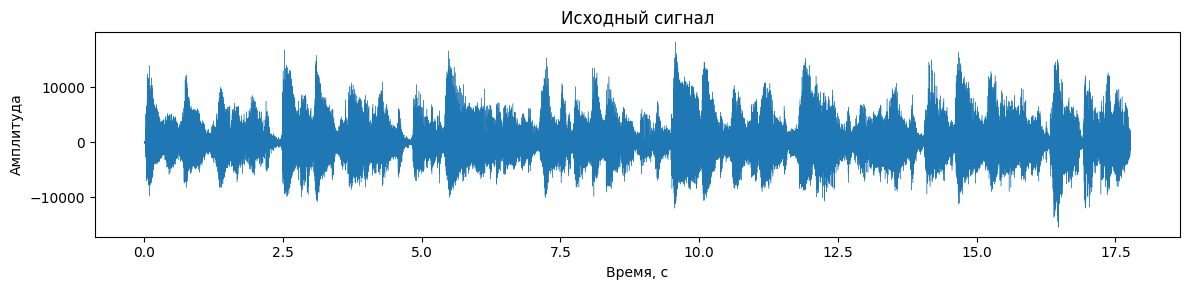

In [88]:
wav_in = wave.open(DATA + "in10.wav", "r")
params = wav_in.getparams()
nchannels, sampwidth, framerate, nframes = params[:4]
raw = wav_in.readframes(nframes)
wav_in.close()

types = {1: np.int8, 2: np.int16, 4: np.int32}
samples = np.frombuffer(raw, dtype=types[sampwidth]).copy()

if nchannels > 1:
    channel = samples[0::nchannels].astype(float)
else:
    channel = samples.astype(float)

plt.figure(figsize=(12, 3))
t = np.arange(len(channel)) / framerate
plt.plot(t, channel, lw=0.3)
plt.xlabel("Время, с"); plt.ylabel("Амплитуда")
plt.title("Исходный сигнал")
plt.tight_layout(); plt.show()

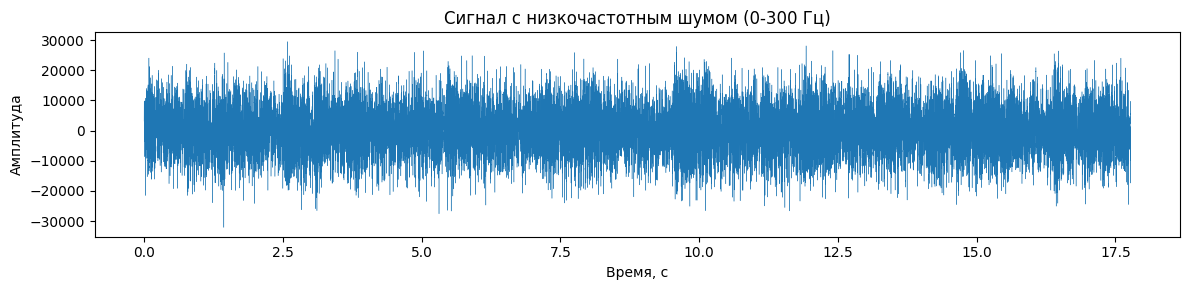

In [89]:
spectrum = np.fft.fft(channel)
freqs = np.fft.fftfreq(len(channel), d=1.0 / framerate)

N = len(spectrum)
noise_amplitude = np.max(np.abs(spectrum)) * 0.3
cutoff_hz = 300
noise_bins = int(cutoff_hz * N / framerate)

np.random.seed(42)
noise_spectrum = np.zeros(N, dtype=complex)
noise_real = np.random.randn(noise_bins) * noise_amplitude
noise_imag = np.random.randn(noise_bins) * noise_amplitude
noise_spectrum[1:noise_bins + 1] = noise_real + 1j * noise_imag
noise_spectrum[N - noise_bins:N] = np.conj(noise_spectrum[1:noise_bins + 1][::-1])

spectrum_noisy = spectrum + noise_spectrum

noisy_signal = np.fft.ifft(spectrum_noisy).real
noisy_signal = np.clip(noisy_signal, -32768, 32767).astype(np.int16)

if nchannels > 1:
    out_samples = np.zeros(nframes * nchannels, dtype=np.int16)
    out_samples[0::nchannels] = noisy_signal
    for ch in range(1, nchannels):
        orig_ch = np.frombuffer(raw, dtype=types[sampwidth])[ch::nchannels]
        out_samples[ch::nchannels] = orig_ch
else:
    out_samples = noisy_signal

wav_out1 = wave.open(DATA + "out1.wav", "wb")
wav_out1.setparams(params)
wav_out1.writeframes(out_samples.tobytes())
wav_out1.close()

plt.figure(figsize=(12, 3))
plt.plot(t, noisy_signal, lw=0.3)
plt.xlabel("Время, с"); plt.ylabel("Амплитуда")
plt.title(f"Сигнал с низкочастотным шумом (0-{cutoff_hz} Гц)")
plt.tight_layout(); plt.show()

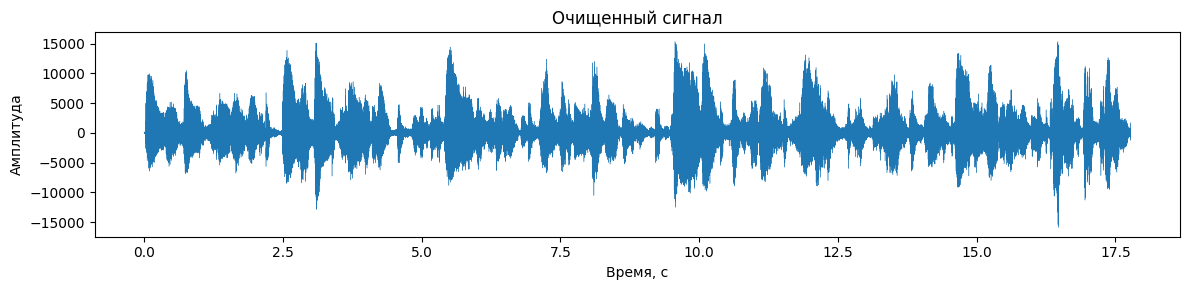

In [90]:
spectrum_cleaned = spectrum_noisy.copy()
spectrum_cleaned[1:noise_bins + 1] = 0
spectrum_cleaned[N - noise_bins:N] = 0

cleaned_signal = np.fft.ifft(spectrum_cleaned).real
cleaned_signal = np.clip(cleaned_signal, -32768, 32767).astype(np.int16)

if nchannels > 1:
    out_samples2 = np.zeros(nframes * nchannels, dtype=np.int16)
    out_samples2[0::nchannels] = cleaned_signal
    for ch in range(1, nchannels):
        orig_ch = np.frombuffer(raw, dtype=types[sampwidth])[ch::nchannels]
        out_samples2[ch::nchannels] = orig_ch
else:
    out_samples2 = cleaned_signal

wav_out2 = wave.open(DATA + "out2.wav", "wb")
wav_out2.setparams(params)
wav_out2.writeframes(out_samples2.tobytes())
wav_out2.close()

plt.figure(figsize=(12, 3))
plt.plot(t, cleaned_signal, lw=0.3)
plt.xlabel("Время, с"); plt.ylabel("Амплитуда")
plt.title("Очищенный сигнал")
plt.tight_layout(); plt.show()

## Задание 3. Быстрое умножение многочленов

In [91]:
def poly_mul_fft(a, b):
    
    result_len = len(a) + len(b) - 1
    n = 1
    while n < result_len:
        n <<= 1
    fa = np.fft.fft(a, n)
    fb = np.fft.fft(b, n)
    fc = fa * fb
    c = np.fft.ifft(fc).real
    return np.round(c[:result_len]).astype(int)

def poly_mul_naive(a, b):

    n = len(a) + len(b) - 1
    c = np.zeros(n, dtype=int)
    for i in range(len(a)):
        for j in range(len(b)):
            c[i + j] += a[i] * b[j]
    return c

In [92]:
a = np.array([1, 2, 3])   
b = np.array([4, 5])          

res_fft = poly_mul_fft(a, b)
res_naive = poly_mul_naive(a, b)

print(f"FFT:{res_fft}")
print(f"Наивно:{res_naive}")

a_big = np.random.randint(0, 100, size=1000)
b_big = np.random.randint(0, 100, size=1000)
assert np.array_equal(poly_mul_fft(a_big, b_big), poly_mul_naive(a_big, b_big))

FFT:[ 4 13 22 15]
Наивно:[ 4 13 22 15]


In [93]:
x = Symbol('x')

sizes = np.linspace(100, 10000, 100).astype(int)
times_fft = []
times_naive = []
times_sympy = []

for n in tqdm(sizes):
    a = np.random.randint(0, 10, size=n)
    b = np.random.randint(0, 10, size=n)

    t0 = time.perf_counter()
    for _ in range(3):
        poly_mul_fft(a, b)
    times_fft.append((time.perf_counter() - t0) / 3)

    if n <= 5000:
        t0 = time.perf_counter()
        poly_mul_naive(a, b)
        times_naive.append(time.perf_counter() - t0)
    else:
        times_naive.append(None)

    pa = Poly(list(reversed(a.tolist())), x, domain='ZZ')
    pb = Poly(list(reversed(b.tolist())), x, domain='ZZ')
    t0 = time.perf_counter()
    for _ in range(3):
        pa * pb
    times_sympy.append((time.perf_counter() - t0) / 3)


100%|██████████| 100/100 [03:59<00:00,  2.40s/it]


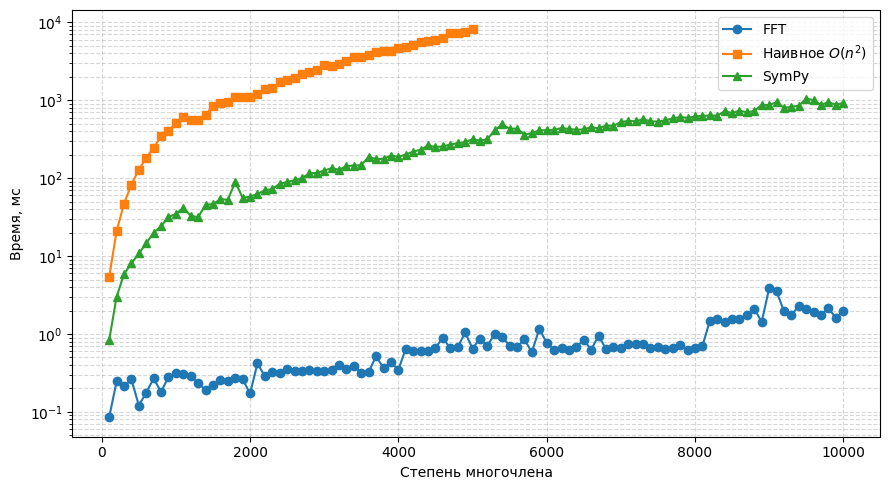

In [95]:
plt.figure(figsize=(9, 5))
plt.plot(sizes, [t * 1000 for t in times_fft], 'o-', label="FFT")

naive_sizes = [s for s, t in zip(sizes, times_naive) if t is not None]
naive_vals = [t * 1000 for t in times_naive if t is not None]
plt.plot(naive_sizes, naive_vals, 's-', label="Наивное $O(n^2)$")

plt.plot(sizes, [t * 1000 for t in times_sympy], '^-', label="SymPy")

plt.yscale('log')

plt.xlabel("Степень многочлена")
plt.ylabel("Время, мс")
plt.legend(); plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout(); plt.show()